tensor([ 2.0001, -0.1399,  1.3085,  6.4788,  0.6808, -0.7177, -0.2843, -1.1649],
       grad_fn=<DivBackward0>)


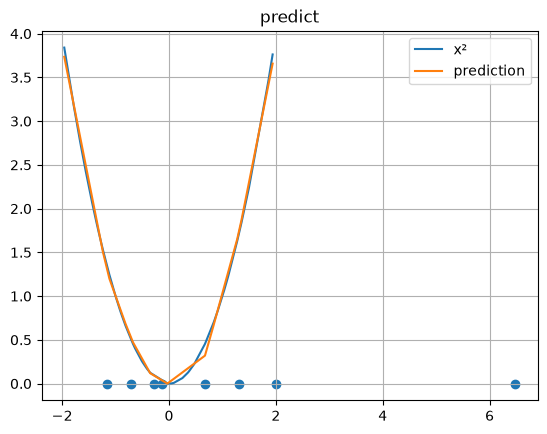

In [6]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt



class MyDataset(Dataset):
    def __init__(self):
        self.x = torch.linspace(-2, 2, 200).reshape(-1, 1)
        self.y = self.x ** 2

    def __len__(self):
        return len(self.x)
    def __getitem__(self,index):
        return self.x[index], self.y[index]

dataset = MyDataset()

train_size = 160
test_size = 40

train_dataset, test_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, test_size]
)

loader = DataLoader(
    train_dataset,
    batch_size=20,
    shuffle=True
)

class My_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(1,8)
        self.linear2 = nn.Linear(8,1)
        self.relu = nn.ReLU()
    def forward(self, x):
        x1 = self.linear1(x)
        x2 = self.relu(x1)
        x3 = self.linear2(x2)
        return x3


model = My_MLP()
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

for epoch in range(1000):
    for x_batch, y_batch in loader:
        optimizer.zero_grad()
        pred = model(x_batch)
        loss = loss_fn(pred,y_batch)
        loss.backward()
        optimizer.step()
    # if epoch % 10 == 0:
    #     print(f"epoch:{epoch}, loss:{loss.item()}")



w = model.linear1.weight.squeeze()
b = model.linear1.bias
points = -b / w
print(points)


x_test = torch.stack([item[0] for item in test_dataset])
y_test = torch.stack([item[1] for item in test_dataset])
y_pred = model(x_test)

sort_idx = torch.argsort(x_test, dim=0).squeeze()

x_test_sorted = x_test[sort_idx]
y_test_sorted = y_test[sort_idx]
y_pred_sorted = y_pred[sort_idx]


# print(x_test,"\n",y_test)

loss_fn2 = torch.nn.MSELoss(reduction='none')
loss_test = loss_fn2(y_pred,y_test)

x_test_np = x_test_sorted.detach().numpy()
y_test_np = y_test_sorted.detach().numpy()
y_pred_np = y_pred_sorted.detach().numpy()
loss_test_np = loss_test.detach().numpy()


plt.title("predict")
plt.plot(x_test_sorted, y_test_np, label="x²")  # 同一个figure的两条线
plt.plot(x_test_sorted, y_pred_np, label="prediction")

plt.scatter(points.detach().numpy(), torch.zeros_like(points).numpy())
plt.legend()
plt.grid()

plt.show()